In [1]:
import matplotlib.pyplot as plt, pandas as pd, numpy as np

In [2]:
file = 'hdh_cdh_integer.csv'
df_file = pd.read_csv(file)

               gcm     ssp     decade  dh  count period
0     CMCC-CM2-SR5  ssp126  2010-2019 -30      1  2010s
1     CMCC-CM2-SR5  ssp126  2010-2019 -29      3  2010s
2     CMCC-CM2-SR5  ssp126  2010-2019 -28      8  2010s
3     CMCC-CM2-SR5  ssp126  2010-2019 -27      8  2010s
4     CMCC-CM2-SR5  ssp126  2010-2019 -26     14  2010s
...            ...     ...        ...  ..    ...    ...
9696    NorESM2-MM  ssp585  2100-2109  14     16  2100s
9697    NorESM2-MM  ssp585  2100-2109  15     15  2100s
9698    NorESM2-MM  ssp585  2100-2109  16     18  2100s
9699    NorESM2-MM  ssp585  2100-2109  17     18  2100s
9700    NorESM2-MM  ssp585  2100-2109  18      9  2100s

[9701 rows x 6 columns]
      ssp period type      mean       std
2  ssp126  2020s  CDH  6.881369  1.755896
       ssp period type      mean       std
20  ssp245  2020s  CDH  8.020525  1.130737
       ssp period type      mean       std
38  ssp370  2020s  CDH  6.656707  0.936884
       ssp period type      mean       std
56  

/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_13868/2953127440.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  CDH_result = CDH_data.groupby(['gcm', 'ssp', 'period']).apply(
/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_13868/2953127440.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  HDH_result = HDH_data.groupby(['gcm', 'ssp', 'period']).apply(


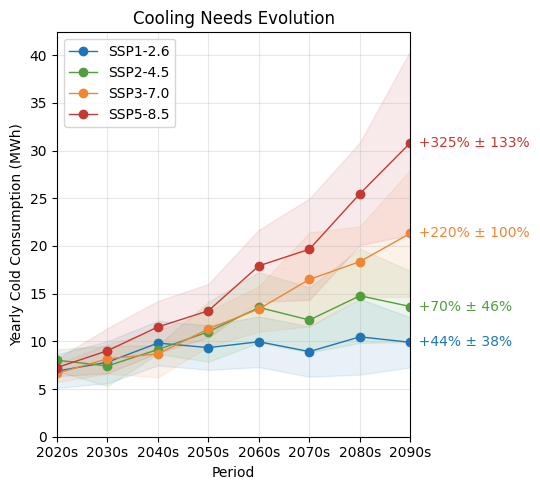

      ssp period type        mean        std
3  ssp126  2020s  HDH  201.462021  15.289603
       ssp period type       mean        std
21  ssp245  2020s  HDH  204.80235  11.358413
       ssp period type        mean        std
39  ssp370  2020s  HDH  209.920938  14.517314
       ssp period type        mean        std
57  ssp585  2020s  HDH  211.778915  15.115746


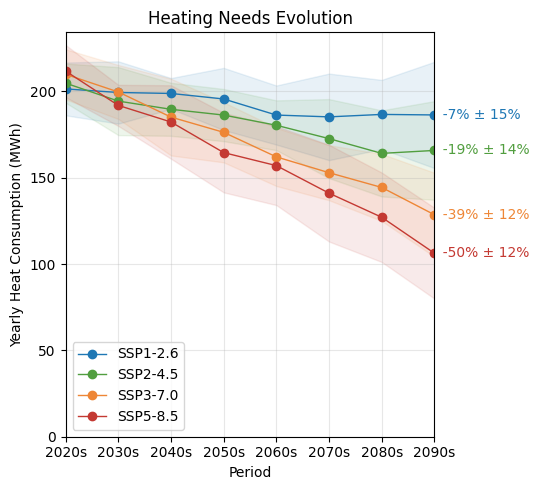

In [95]:
print(df_file)
# Case study
U = 1.5
A = 29480

colors = {
    'ssp126': ( 30/255,119/255,180/255),
    'ssp245': ( 81/255,158/255, 63/255),
    'ssp370': (238/255,134/255, 54/255),
    'ssp585': (196/255, 57/255, 50/255)
}

# Create period column
df_file['period'] = df_file['decade'].apply(lambda x: x[0:4] + 's')

# CDH - for dh > 0 (Cooling Degree Hours)
CDH_data = df_file.loc[(df_file['dh'] > 0) & (df_file['period'] != '2100s')]
CDH_result = CDH_data.groupby(['gcm', 'ssp', 'period']).apply(
    lambda x: (U * A * x['dh'] * x['count']).sum() / 6 / 10 / 1e6
).reset_index(name='value')
CDH_result['type'] = 'CDH'  # Add type identifier

# HDH - for dh < 0 (Heating Degree Hours)
HDH_data = df_file.loc[(df_file['dh'] < 0) & (df_file['period'] != '2100s')]
HDH_result = HDH_data.groupby(['gcm', 'ssp', 'period']).apply(
    lambda x: (- U * A * x['dh'] * x['count']).sum() / 6 / 10 / 1e6
).reset_index(name='value')
HDH_result['type'] = 'HDH'  # Add type identifier

# Combine both results
combined_result = pd.concat([CDH_result, HDH_result], ignore_index=True)

# Sort for better readability
combined_result = combined_result.sort_values(['gcm', 'ssp', 'period', 'type'])
# Compute mean and variance grouped by ssp, period, type (aggregating over gcms)
stats_result = combined_result.groupby(['ssp', 'period', 'type'])['value'].agg(['mean', 'std']).reset_index()

# Create separate plots for each type
for energy_type in stats_result['type'].unique():
    plt.figure(figsize=(5.5, 5))
    
    # Filter data for current type
    type_data = stats_result[stats_result['type'] == energy_type]
    
    # Plot each ssp
    for ssp in type_data['ssp'].unique():
        thelegend = f'SSP{ssp[3]}-{ssp[4]}.{ssp[5]}'
        ssp_data = type_data[type_data['ssp'] == ssp].sort_values('period')
        
        plt.plot(ssp_data['period'], ssp_data['mean'], 
                color=colors[ssp], label=thelegend, linewidth=1, marker = 'o')
        plt.fill_between(ssp_data['period'], 
                        ssp_data['mean'] - ssp_data['std'],
                        ssp_data['mean'] + ssp_data['std'],
                        color=colors[ssp], alpha=0.1)
        print(ssp_data.loc[(ssp_data['period'] == '2020s')])
        mean_start = ssp_data.loc[(ssp_data['period'] == '2020s'),'mean'].iloc[0]
        mean_end = ssp_data.loc[(ssp_data['period'] == '2090s'),'mean'].iloc[0]
        std_end = ssp_data.loc[(ssp_data['period'] == '2090s'),'std'].iloc[0]
        sign = '+' if mean_start < mean_end else ''
        plt.annotate(f'  {sign}{(mean_end - mean_start)/mean_start:.0%} ± {std_end/mean_start:.0%}',xy = (8,mean_end), va = 'center', color = colors[ssp])
    required = 'Heating' if energy_type == 'HDH' else 'Cooling'
    required2 = 'Heat' if energy_type == 'HDH' else 'Cold'
    plt.title(f'{required} Needs Evolution')
    plt.xlabel('Period')
    plt.ylabel(f'Yearly {required2} Consumption (MWh)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom = 0)
    plt.xlim(left=1, right = 8)
    plt.tight_layout()
    plt.savefig(f'{required} Needs Evolution.pdf')
    plt.show()

Plotting for SSP: None, Decade: 2010-2019
Number of GCMs: 6
Number of SSPs: 4
DH values range: -33 to 17

Summary statistics:
Mean counts range: nan to nan
Standard deviations range: nan to nan


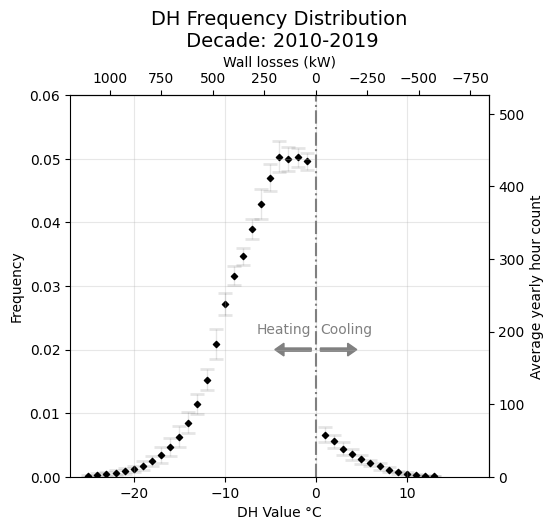

ssp126
Plotting for SSP: ssp126, Decade: 2050-2059
Number of GCMs: 6
Number of SSPs: 1
DH values range: -30 to 15

Summary statistics:
Mean counts range: nan to nan
Standard deviations range: nan to nan
ssp245
Plotting for SSP: ssp245, Decade: 2050-2059
Number of GCMs: 6
Number of SSPs: 1
DH values range: -28 to 20

Summary statistics:
Mean counts range: nan to nan
Standard deviations range: nan to nan
ssp370
Plotting for SSP: ssp370, Decade: 2050-2059
Number of GCMs: 6
Number of SSPs: 1
DH values range: -28 to 17

Summary statistics:
Mean counts range: nan to nan
Standard deviations range: nan to nan
ssp585
Plotting for SSP: ssp585, Decade: 2050-2059
Number of GCMs: 6
Number of SSPs: 1
DH values range: -27 to 19

Summary statistics:
Mean counts range: nan to nan
Standard deviations range: nan to nan


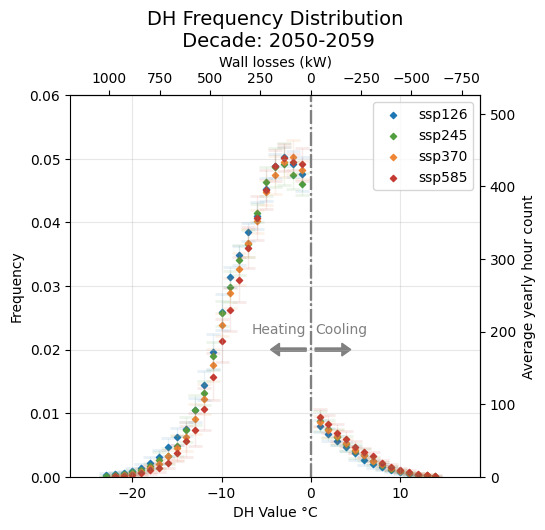

In [27]:
def plot_dh_barplot_with_variance(df, decade, ssp = None,  dh_column='dh', count_column='count', color = 'blue', fig = None):
    if ssp != None:
        # Filter data for the specified SSP and decade
        filtered_df = df[(df['ssp'] == ssp) & (df['decade'] == decade)].copy()
    else:
        # Filter data for the specified SSP and decade
        filtered_df = df[(df['decade'] == decade)].copy()
    
    if filtered_df.empty:
        print(f"No data found for SSP {ssp} and decade {decade}")
        return
    
    # Get unique DH values and GCMs
    dh_values = sorted(filtered_df[dh_column].unique())
    gcms = filtered_df['gcm'].unique()
    ssps = filtered_df['ssp'].unique()
    
    print(f"Plotting for SSP: {ssp}, Decade: {decade}")
    print(f"Number of GCMs: {len(gcms)}")
    print(f"Number of SSPs: {len(ssps)}")
    print(f"DH values range: {min(dh_values)} to {max(dh_values)}")
    # Get total counts per GCM to convert to frequencies
    total_counts_per_gcm = filtered_df.groupby('gcm')[count_column].sum()
    
    # Use groupby to get frequencies
    pivot_df = (filtered_df.groupby(['gcm', dh_column])[count_column]
                .sum()
                .reset_index())
    
    # Convert counts to frequencies
    pivot_df['frequency'] = pivot_df.apply(
        lambda row: row[count_column] / total_counts_per_gcm[row['gcm']], 
        axis=1
    )
    
    # Pivot to matrix format
    count_matrix = (pivot_df.pivot(index='gcm', columns=dh_column, values='frequency')
                    .reindex(columns=dh_values, fill_value=0)
                    .values)
    
    # Calculate statistics
    means = np.mean(count_matrix, axis=0)
    stds = np.std(count_matrix, axis=0)
    
    # Create the plot
    if fig == None:
        plt.figure(figsize=(10, 5))
    
    # Create bar positions
    x_pos = np.arange(len(dh_values))
    
    # Plot bars
    bars = plt.scatter(dh_values, means, color=color, 
                   alpha=1.0, label=ssp, marker = 'D', s = 10)
    
    
    # Add error bars for standard deviation
    plt.errorbar(dh_values, means, yerr=stds, fmt='none', color=color, alpha = 0.1,
                 capsize=5, capthick=2, elinewidth=1)
    
    # Customize the plot
    plt.xlabel('DH Value °C', fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.title(f'DH Frequency Distribution\n Decade: {decade}', fontsize=14)
    
    # Set x-axis ticks and labels
    # plt.xticks(x_pos, dh_values, rotation=45 if len(dh_values) > 20 else 0)
    
    # Add grid for better readability
    # plt.grid(True, alpha=0.3, axis='y')
    
    # Add legend
    if ssp != None:
        plt.legend()
    
    # Add some statistics to the plot
    max_mean = np.max(means)
    max_std = np.max(stds)
    # plt.text(0.02, 0.98, f'Max mean: {max_mean:.1f}\nMax std: {max_std:.1f}', 
    #          transform=plt.gca().transAxes, verticalalignment='top',
    #          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    # plt.yscale('log')
    plt.vlines(0,ymin=1e-10, ymax=1,color ='gray', linestyle = '-.')
    plt.ylim(bottom = 0, top = 0.06)
    plt.xlim(left = -27, right = 19)
    
    if fig == None:
        plt.show()
    
    # Print some summary statistics
    print(f"\nSummary statistics:")
    print(f"Mean counts range: {np.min(means):.2f} to {np.max(means):.2f}")
    print(f"Standard deviations range: {np.min(stds):.2f} to {np.max(stds):.2f}")
    
    return means, stds, dh_values


# plt.figure()
fig, ax = plt.subplots(figsize=(5, 5))
plot_dh_barplot_with_variance(df_file, ssp=None, decade = '2010-2019', dh_column='dh', count_column='count', color = 'black', fig = True)

# Add arrow
ax.arrow(0.5, 0.02, 3.0, 0.0, width = 0.0005,
          head_width=0.002, head_length=1, fc='gray', ec='gray')

ax.arrow(-0.5, 0.02, -3.0, 0.0, width = 0.0005,
          head_width=0.002, head_length=1, fc='gray', ec='gray')

# Add text
ax.text(0.5, 0.022, "Cooling", ha='left', va='bottom', color = 'gray')
ax.text(-0.5, 0.022, "Heating", ha='right', va='bottom', color = 'gray')

# This works:
# ax = plt.gca()

# Forward: convert primary axis values to secondary axis values
def forward(x):
    return x * U * A / scalar

# Inverse: convert secondary axis values back to primary axis values  
def inverse(x):
    return x * scalar / (U * A)

secax_x = ax.secondary_xaxis('top', functions=(lambda x: - x * U * A / 1e3, lambda x: - x * 1e3 / (U * A)))
secax_x.set_xlabel('Wall losses (kW)')
scalar = 8760
secax_y = ax.secondary_yaxis('right', functions=(lambda x: x*8760, lambda x: x/8760))
secax_y.set_ylabel('Average yearly hour count')
ax.grid(True, alpha=0.3)
secax_y.grid(True, alpha=0.3)
plt.savefig('distribution_T_now.pdf',bbox_inches='tight', pad_inches=0.1)
plt.show()

# plt.figure(figsize=(10, 5))
# for ssp in df_file['ssp'].unique():
#     print(ssp)
#     plot_dh_barplot_with_variance(df_file, ssp=ssp, decade = '2050-2059', dh_column='dh', count_column='count', color = colors[ssp], fig =True)


fig, ax = plt.subplots(figsize=(5, 5))
for ssp in df_file['ssp'].unique():
    print(ssp)
    plot_dh_barplot_with_variance(df_file, ssp=ssp, decade = '2050-2059', dh_column='dh', count_column='count', color = colors[ssp], fig =True)
    

# Add arrow
plt.arrow(0.5, 0.02, 3.0, 0.0, width = 0.0005,
          head_width=0.002, head_length=1, fc='gray', ec='gray')

plt.arrow(-0.5, 0.02, -3.0, 0.0, width = 0.0005,
          head_width=0.002, head_length=1, fc='gray', ec='gray')

# Add text
plt.text(0.5, 0.022, "Cooling", ha='left', va='bottom', color = 'gray')
plt.text(-0.5, 0.022, "Heating", ha='right', va='bottom', color = 'gray')

# This works:

# Forward: convert primary axis values to secondary axis values
def forward(x):
    return x * U * A / scalar

# Inverse: convert secondary axis values back to primary axis values  
def inverse(x):
    return x * scalar / (U * A)

secax_x = ax.secondary_xaxis('top', functions=(lambda x: - x * U * A / 1e3, lambda x: - x * 1e3 / (U * A)))
secax_x.set_xlabel('Wall losses (kW)')

scalar = 8760
secax_y = ax.secondary_yaxis('right', functions=(lambda x: x*scalar, lambda x: x/scalar))
secax_y.set_ylabel('Average yearly hour count')
ax.grid(True, alpha=0.3)
plt.savefig('distribution_T_mid_century.pdf',bbox_inches='tight', pad_inches=0.1)